**Install Kaggle Library**

In [1]:
!pip install kaggle


   -------- -------------------------------  2/10 [python-slugify]
   ------------ ---------------------------  3/10 [protobuf]
   -------------------- -------------------  5/10 [markdown-it-py]
   ------------------------ ---------------  6/10 [kagglesdk]
   ------------------------ ---------------  6/10 [kagglesdk]
   ------------------------ ---------------  6/10 [kagglesdk]
   ------------------------ ---------------  6/10 [kagglesdk]
   ---------------------------- -----------  7/10 [mdit-py-plugins]
   -------------------------------- -------  8/10 [jupytext]
   ------------------------------------ ---  9/10 [kaggle]
   ---------------------------------------- 10/10 [kaggle]




[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Using kaggle api key**

In [51]:
import os

os.environ["KAGGLE_USERNAME"] = "sinmbflost"
os.environ["KAGGLE_KEY"] = "KGAT_a99f586343e2ccb0e578a28a67335d03"

**Importing Kaggle Dataset**

In [52]:
# API to fetch the dataset from kaggle

!kaggle datasets download omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [53]:
# extracting the compressed Dataset

from zipfile import ZipFile
dataset='/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print("The dataset is extracted")


The dataset is extracted


**Importing the Dependencies**

In [54]:
import os # access files
import numpy as np # convert images to numpy arrays

# for viualizing images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# for image processing
import cv2
from PIL import Image

# creates a new window and display image in that window
from google.colab.patches import cv2_imshow

# split our data into training data
from sklearn.model_selection import train_test_split


**Analyze the images**

In [55]:
# create a list which contains all the file names present with_mask folder
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])


['with_mask_1572.jpg', 'with_mask_2988.jpg', 'with_mask_1043.jpg', 'with_mask_1909.jpg', 'with_mask_999.jpg']
['with_mask_128.jpg', 'with_mask_1543.jpg', 'with_mask_1200.jpg', 'with_mask_510.jpg', 'with_mask_556.jpg']


In [56]:
# create a list which contains all the file names present without_mask folder
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_3445.jpg', 'without_mask_3325.jpg', 'without_mask_2287.jpg', 'without_mask_3705.jpg', 'without_mask_643.jpg']
['without_mask_399.jpg', 'without_mask_2294.jpg', 'without_mask_2718.jpg', 'without_mask_2976.jpg', 'without_mask_7.jpg']


In [57]:
# check the number of images in both folder to balance them
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


Both classes of image are close to equal. So no problem.

**Creating Labels for the two class of images**

with mask --> 1

without mask --> 0

In [58]:
# create the labels

'''
  Create two lists:
    - First list that contains only 1's and it's length will be equal to the
      with mask image class

    - Another list that contains only 0's and it's length will be equal to the
      without mask image class
'''
with_mask_labels = [1] * len(with_mask_files)

without_mask_labels = [0] * len(without_mask_files)

In [59]:
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [60]:
# check if the new lists are equal in length to the classes of image

print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [61]:
# combine the new latest lists
labels = with_mask_labels + without_mask_labels # if numpy array then '+' adds the values otherwise combines

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the Images**

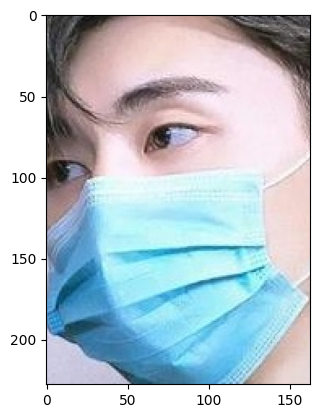

In [62]:
# display with mask image

# First read image in the form of numpy array
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')

# Then display it in a matplotlib plot using pyplot
imgplot = plt.imshow(img)
plt.show()


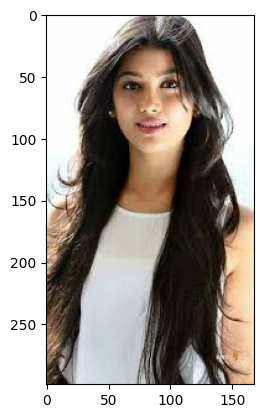

In [63]:
# display without mask image

# First read image in the form of numpy array
img = mpimg.imread('/content/data/without_mask/without_mask_1545.jpg')

# Then display it in a matplotlib plot using pyplot
imgplot = plt.imshow(img)
plt.show()

Right now, all the images have different width and height. We need to make them uniform later during image processing.

**Image Processing**

Things to do:

1. Resize the images
2. Convert the images to numpy arrays

In [64]:
# convert images to numpy array

# for with mask images
with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  # Image.open converts the image to a pillow object that contains resize property
  image = Image.open(with_mask_path + img_file)
  # convert the image to a standard size
  image = image.resize((128,128)) # (height, width)
  # convert all images to RGB to prevent some being read as black and white image
  image = image.convert('RGB')
  # convert image object into numpy array
  image = np.array(image)
  data.append(image)

# for without mask images
without_mask_path = '/content/data/without_mask/'

for img_file in without_mask_files:

  # Image.open converts the image to a pillow object that contains resize property
  image = Image.open(without_mask_path + img_file)
  # convert the image to a standard size
  image = image.resize((128,128)) # (height, width)
  # convert all images to RGB to prevent some being read as black and white image
  image = image.convert('RGB')
  # convert image object into numpy array
  image = np.array(image)
  data.append(image)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [65]:
type(data)

list

In [66]:
len(data)

7553

array([[[255, 255, 253],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [207, 208, 198],
        [212, 211, 206],
        [179, 176, 173]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [228, 229, 223],
        [210, 209, 207],
        [177, 173, 175]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 254],
        ...,
        [231, 231, 227],
        [206, 205, 206],
        [191, 186, 192]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 54,  54,  64],
        [ 44,  44,  54],
        [ 55,  55,  65]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 40,  40,  50],
        [ 52,  52,  62],
        [ 40,  40,  50]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 41,  41,  51],
        [ 44,  44,  54],
        [ 28,  28,  38]]], dtype=uint8)
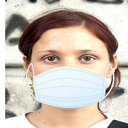

In [67]:
data[0] # prints pixel values

In [68]:
type(data[0])

numpy.ndarray

In [69]:
data[0].shape # (height, width, color channel-RGB)


(128, 128, 3)

In [70]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [71]:
type(X)

numpy.ndarray

In [72]:
type(Y)

numpy.ndarray

In [73]:
print(X.shape) # (number of numpy arrays contained, height, width, color channel-RGB)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [74]:
print(Y)

[1 1 1 ... 0 0 0]


**Train Test Split**

In [75]:
# While doing train test split, the data will be splited randomly, to make sure
# data is splited in the same way, provide random_state value

# test_size -> how much data to be tested, in this case, 20% = 0.2

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [76]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [77]:
# scaling the data - for better performance of the model

# we get values between 0 and 1, 0 -> white, 1 -> black

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[141, 164, 169],
        [119, 142, 148],
        [ 66,  89,  98],
        ...,
        [ 68, 107, 146],
        [ 65, 103, 142],
        [109, 147, 186]],

       [[140, 164, 169],
        [108, 131, 137],
        [ 59,  82,  91],
        ...,
        [ 71, 109, 148],
        [ 93, 131, 170],
        [ 97, 135, 174]],

       [[119, 144, 149],
        [ 87, 111, 118],
        [ 50,  72,  83],
        ...,
        [ 42,  80, 119],
        [ 84, 122, 161],
        [123, 161, 200]],

       ...,

       [[ 17,  20,  26],
        [ 18,  21,  26],
        [ 18,  21,  26],
        ...,
        [220, 210, 198],
        [222, 214, 203],
        [226, 217, 206]],

       [[ 16,  19,  24],
        [ 16,  19,  24],
        [ 18,  21,  26],
        ...,
        [219, 212, 198],
        [221, 216, 204],
        [224, 219, 208]],

       [[ 16,  20,  23],
        [ 17,  20,  24],
        [ 18,  21,  26],
        ...,
        [221, 217, 202],
        [221, 218, 206],
        [223, 221, 208]]], dtype=uint8)
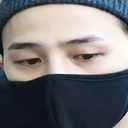

In [78]:
X_train[0]

In [79]:
X_train_scaled[0]

array([[[0.55294118, 0.64313725, 0.6627451 ],
        [0.46666667, 0.55686275, 0.58039216],
        [0.25882353, 0.34901961, 0.38431373],
        ...,
        [0.26666667, 0.41960784, 0.57254902],
        [0.25490196, 0.40392157, 0.55686275],
        [0.42745098, 0.57647059, 0.72941176]],

       [[0.54901961, 0.64313725, 0.6627451 ],
        [0.42352941, 0.51372549, 0.5372549 ],
        [0.23137255, 0.32156863, 0.35686275],
        ...,
        [0.27843137, 0.42745098, 0.58039216],
        [0.36470588, 0.51372549, 0.66666667],
        [0.38039216, 0.52941176, 0.68235294]],

       [[0.46666667, 0.56470588, 0.58431373],
        [0.34117647, 0.43529412, 0.4627451 ],
        [0.19607843, 0.28235294, 0.3254902 ],
        ...,
        [0.16470588, 0.31372549, 0.46666667],
        [0.32941176, 0.47843137, 0.63137255],
        [0.48235294, 0.63137255, 0.78431373]],

       ...,

       [[0.06666667, 0.07843137, 0.10196078],
        [0.07058824, 0.08235294, 0.10196078],
        [0.07058824, 0

**Building Convolutional Neural Network (CNN)**

In [80]:
# tensorflow used to develop neural network - made by google
import tensorflow as tf

# keras is wrapper for the library
from tensorflow import keras

In [81]:
num_of_classes = 2

model = keras.Sequential()

# add layers - convolutional and max pooling layers
# input_shape should only be present in the first layer
model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3))) # (filter, )
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu')) # (filter, )
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

# add flatten layer to conver the 2D data into a single dimension
# we can't pass 2D data in the form of matrix so we convert it into vector - 1D
model.add(keras.layers.Flatten())

# Add dense/hidden layers - all neurons in this layer is connected to the neurons of the
# previous layers
model.add(keras.layers.Dense(128, activation='relu')) # (total number of neurons,)

# Make sure there is no overfitting issues by turning off some of the neurons
model.add(keras.layers.Dropout(0.5))

# Add another dense layer
model.add(keras.layers.Dense(64, activation='relu')) # (total number of neurons,)
model.add(keras.layers.Dropout(0.5))

# sigmoid activation function used in binary classification problems
model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
# compile the neural network - set optimization alogrithm and loss function matrix for the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # numerical enoder labels so sparse_..
              metrics=['acc']) # accuracy



In [83]:
# Training the neural network

# store training check points in history
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

# validation_split = 10% -> training will be done on 90% data,
#                           on the remaining 10%, validation will be performed

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - acc: 0.7876 - loss: 0.4686 - val_acc: 0.8893 - val_loss: 0.2621
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8771 - loss: 0.3005 - val_acc: 0.8909 - val_loss: 0.2333
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - acc: 0.9066 - loss: 0.2445 - val_acc: 0.9124 - val_loss: 0.2211
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9193 - loss: 0.2051 - val_acc: 0.8975 - val_loss: 0.2284
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9340 - loss: 0.1721 - val_acc: 0.9157 - val_loss: 0.1858


**Model Evaluation:**

Do model evaluation on test data to make sure the model in performing well on
unknown data set

In [84]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy:', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9285 - loss: 0.2097
Test Accuracy: 0.9285241365432739


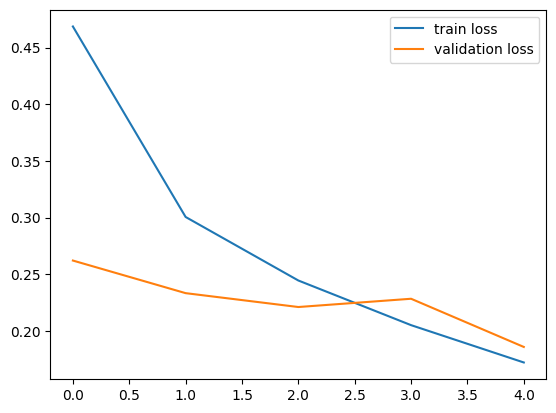

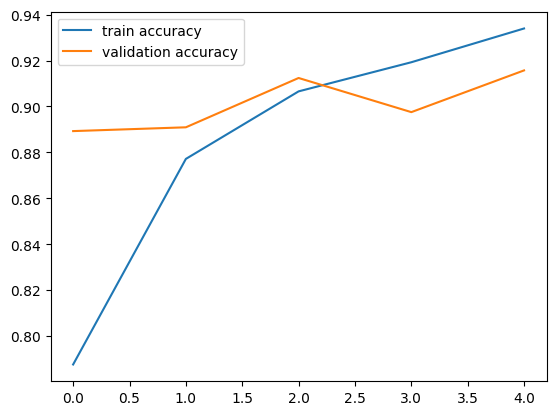

In [85]:
# visualize
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

**Predictive System**

Path of the image to be predicted: /content/test_w2.jpg


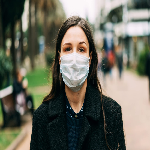

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.11528311 0.918843  ]]
1
The person in the image is wearing a mask


In [124]:
# read image
input_image_path = input('Path of the image to be predicted: ')

# convert the image into numpy array - cv2.imread reads image in BGR format
input_image = cv2.imread(input_image_path)

# check image loaded
if input_image_bgr is None:
    print("Image not found")
    exit()

# display image
cv2_imshow(cv2.resize(input_image,(150,150)))

# convert BGR to RGB since our model expects RGB
input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

# To tell the model that we are only predicting for one image
input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

# get prediction as probability values
# 2 neurons -> 1 neuron gives for wearing mask and another not wearing mask
input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

# convert the probability values to respective label values
input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 1:
  print("The person in the image is wearing a mask")
else:
  print("The person in the image is not wearing a mask")

In [ ]:
# Create a model.h5 file for streamlit
model.save('model.h5')
print("Model saved!")